# 10. Unsupervised Learning

---

> **Unsupervised Learning**: Modelle erhalten nur Eingabedaten $X = \{x_1, \dots, x_n\}$, aber **keine Labels** $y$. Ziel ist es, Strukturen, Muster oder Regularitäten in den Daten selbst zu erkennen.

## 10.1 Motivation

Bisher haben wir ausschließlich **Supervised Learning** betrieben: Zu jedem Datenpunkt $x_i$ gab es ein bekanntes Label $y_i$ (z. B. `survived`), und unsere Modelle lernten die Abbildung $x \mapsto y$.

Im Alltag liegen jedoch sehr oft **keine Labels** vor – trotzdem wollen wir etwas über die Daten lernen:

* Welche Punkte gehören zusammen?
* Welche Richtung erklärt die meiste Variation in den Daten?
* Wo ist die Dichte der Daten hoch, wo niedrig?

**Wichtiger Unterschied zum Supervised Learning:**

> Es gibt kein „richtig" oder „falsch" – nur **nützlich oder nicht nützlich**.

### Anwendungsfelder

* **Explorative Datenanalyse** – Muster, Struktur, Ausreißer entdecken; Daten visualisieren (z. B. PCA für 2D)
* **Segmentierung / Clustering** – Kundensegmente, Nutzergruppen, Patiententypen
* **Anomalieerkennung** – Fraud, Produktionsfehler, ungewöhnliche Sensorwerte
* **Dimensionsreduktion** – Rauschen reduzieren, Daten komprimieren, Feature-Extraktion für nachfolgende Modelle
* **Representation Learning** – latente Faktoren in Bildern, Texten, Genomdaten

Dieses Notebook gibt einen **kompakten Überblick** über die wichtigsten Ideen des Unsupervised Learning und vertieft die beiden praktisch wichtigsten Methoden – **k-Means Clustering** und **Principal Component Analysis (PCA)** – anhand von Beispielen.


## 10.2 Ablauf dieses Notebooks

1. Die vier Hauptfamilien des Unsupervised Learning im Überblick
2. Daten für dieses Notebook (Titanic & Digits)
3. k-Means Clustering – Intuition, Algorithmus, Praxis
4. Principal Component Analysis (PCA) – Intuition, Mathematik, Praxis
5. Ausblick: weitere Methoden
6. Fazit


## Kapitel 1: Die vier Hauptfamilien des Unsupervised Learning

### 1. Clustering
**Ziel:** Gruppen ähnlicher Punkte finden.
**Methoden:** k-Means, Hierarchical Clustering, DBSCAN.

**Konkretes Beispiel – Kundensegmente im Online-Shop:** Anhand von Anzahl Käufen, Warenkorbgrößen, Besuchshäufigkeit und Retourenquote findet k-Means z. B. drei Cluster: „Preisbewusste" (kleine Warenkörbe, wenige Besuche), „Premiumkäufer" (hohe Warenkörbe, hohe Loyalität) und „Stöbernde Nutzer" (viele Besuche, selten Käufe). Das Modell erkennt diese Gruppen **rein aus dem Verhalten** – ohne zu wissen, welche „Kundentypen" überhaupt existieren.

### 2. Dimensionsreduktion
**Ziel:** Struktur erhalten, Dimensionen reduzieren.
**Methoden:** linear – PCA; nichtlinear – t-SNE, UMAP.

**Konkretes Beispiel – Wohnungsdaten auf 2D reduzieren:** Eine Wohnung hat 50 Eigenschaften (Quadratmeter, Zimmer, Baujahr, Lärmpegel etc.). PCA fasst sie zu 2 Hauptachsen zusammen: **Größe/Platz** und **Lage/Komfort**. Im 2D-Diagramm liegen ähnliche Wohnungen eng zusammen. Das Modell ignoriert unwichtige Details (z. B. Steckdosenanzahl) und behält die **Hauptvariationen** bei.

### 3. Dichteschätzung
**Ziel:** Die Verteilung $p(x)$ der Daten modellieren.
**Methoden:** Kernel Density Estimation (KDE), Gaussian Mixture Models (GMM).

**Konkretes Beispiel – Kreditkartenbetrug:** Aus vielen normalen Transaktionen (typische Beträge, Orte, Uhrzeiten) entsteht eine „Landkarte" der Dichte: Wo kommen viele Transaktionen vor (hohe Dichte), wo fast keine (niedrige Dichte)? Eine neue Transaktion über 1.000 € nachts auf einem anderen Kontinent liegt in einem Bereich mit sehr niedriger Dichte $\Rightarrow$ „ungewöhnlich" $\Rightarrow$ möglicher Betrug. Das Modell lernt nur, was normal häufig ist, und markiert alles, was extrem selten vorkommt.

### 4. Representation / Latent Space Learning
**Ziel:** kompakte, bedeutungsvolle Repräsentationen lernen.
**Methoden:** Autoencoder, Embedding-Modelle.

**Konkretes Beispiel – Wort-Embeddings:** Aus vielen Sätzen wie „Der Hund spielt im Garten" und „Die Katze schläft im Garten" beobachtet ein Modell, dass „Hund" und „Katze" oft an ähnlichen Stellen und neben ähnlichen Verben stehen. Das Resultat: Jedes Wort erhält einen Vektor (z. B. 50-dimensional), wobei Wörter mit ähnlicher Bedeutung räumlich nah beieinanderliegen – bekanntes Beispiel: $\text{König} - \text{Mann} + \text{Frau} \approx \text{Königin}$. Das Modell lernt Bedeutungsähnlichkeiten rein aus dem gemeinsamen Auftreten der Wörter, ganz ohne Definitionen.


### Fazit Kapitel 1

Alle vier Familien haben ein gemeinsames Prinzip: Sie extrahieren **Struktur** aus $X$ allein, ohne dass jemand vorher gesagt hat, was „richtig" ist. In diesem Notebook vertiefen wir **Clustering** (am Beispiel k-Means) und **Dimensionsreduktion** (am Beispiel PCA), da diese beiden Methoden in der Praxis am häufigsten eingesetzt werden und sich mathematisch besonders gut greifen lassen. Dichteschätzung und Representation Learning bleiben konzeptionelle Bausteine für weiterführende Veranstaltungen (siehe Kapitel 5).


## Kapitel 2: Daten für dieses Notebook

Wir verwenden zwei Datensätze, die zu den beiden Methoden passen:

* **Titanic** (bereits bekannt) – ein klassischer tabellarischer Datensatz. Wir ignorieren hier bewusst die Zielvariable `survived` während des Trainings der unsupervised Modelle – schauen sie uns aber **danach** an, um die gefundenen Muster zu interpretieren. Das ist ein sehr gängiges Vorgehen: Labels sind zwar vorhanden, werden aber nicht zum Training genutzt, sondern nur zur nachträglichen Bewertung.
* **Digits** – ein kleiner, in `scikit-learn` eingebauter Bilddatensatz (handgeschriebene Ziffern, $8\times 8$ Pixel = 64 Dimensionen), der ohne Internetzugriff funktioniert und uns als kompaktes Analogon zum in der Vorlesung genannten MNIST-Beispiel ($28\times 28$ Pixel) dient.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Titanic-Datensatz laden (wie in den vorherigen Notebooks)
df = sns.load_dataset("titanic")

target_col = "survived"
drop_cols = [target_col, "alive", "class"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df[target_col].copy()  # wird NICHT zum Clustern verwendet, nur zur späteren Interpretation

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "bool", "category"]).columns.tolist()

# Preprocessing-Pipeline (Imputation, Standardisierung, One-Hot-Encoding)
# sparse_output=False, da PCA und die Distanzberechnung in k-Means dichte Matrizen benötigen
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

X_trans = preprocess.fit_transform(X)
feature_names_all = preprocess.get_feature_names_out()

print("Shape der transformierten Titanic-Daten:", X_trans.shape)
print("Zielverteilung (nur zur späteren Interpretation):")
print(y.value_counts(normalize=True))

Shape der transformierten Titanic-Daten: (891, 27)
Zielverteilung (nur zur späteren Interpretation):
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


c:\temp\ipykernel_31700\1740494834.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "bool", "category"]).columns.tolist()


Shape der Digits-Daten: (1797, 64)
Klassen (Ziffern 0-9): [0 1 2 3 4 5 6 7 8 9]


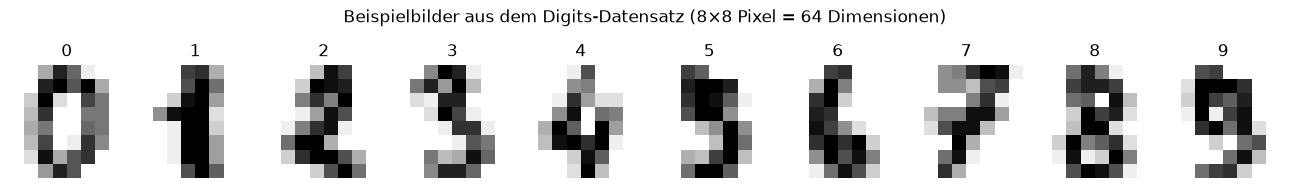

In [2]:
from sklearn.datasets import load_digits

digits = load_digits()
print("Shape der Digits-Daten:", digits.data.shape)  # (n_samples, 64)
print("Klassen (Ziffern 0-9):", np.unique(digits.target))

fig, axes = plt.subplots(1, 10, figsize=(13, 2))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap="gray_r")
    ax.set_title(str(digits.target[i]))
    ax.axis("off")
plt.suptitle("Beispielbilder aus dem Digits-Datensatz (8×8 Pixel = 64 Dimensionen)")
plt.tight_layout()
plt.show()

### Fazit Kapitel 2

Wir haben zwei komplementäre Datensätze vorbereitet:

* Die **Titanic-Daten** (transformiert, standardisiert, one-hot-kodiert) für Clustering und PCA auf tabellarischen Daten.
* Die **Digits-Daten** als kompaktes Bildbeispiel, um die Wirkung von PCA auf hochdimensionale Bilddaten zu demonstrieren – analog zum MNIST-Beispiel der Vorlesung.

Auf beiden Datensätzen wenden wir nun zunächst **k-Means Clustering** an.


## Kapitel 3: k-Means Clustering

### Intuition

**Frage:** Wie können wir Punkte so gruppieren, dass jede Gruppe intern möglichst ähnlich ist?

**Idee von k-Means:**

1. Lege $k$ Punkte (**Centroids**) in den Raum.
2. Jeder Datenpunkt gehört zu dem Zentrum, dem er am nächsten ist.
3. Schiebe die Zentren so lange hin und her, bis sie „gut" in der Mitte ihrer Gruppen liegen.

„Ähnlich" bedeutet hier: nahe beieinander im Sinne der euklidischen Distanz. Das Ergebnis: Der Raum wird in $k$ Regionen aufgeteilt – jede mit einem eigenen Zentrum.


c:\Users\zieher\AppData\Local\miniconda3\envs\mll\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


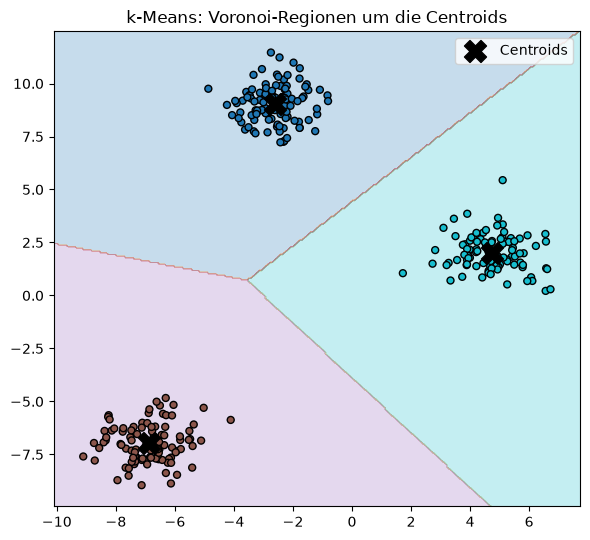

In [3]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X_blobs, y_true_blobs = make_blobs(n_samples=300, centers=3, cluster_std=0.9, random_state=42)

kmeans_demo = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_demo = kmeans_demo.fit_predict(X_blobs)
centers_demo = kmeans_demo.cluster_centers_

# Gitter für die Hintergrundfärbung (zeigt, welchem Zentrum jeder Punkt im Raum am nächsten ist)
xx, yy = np.meshgrid(
    np.linspace(X_blobs[:, 0].min() - 1, X_blobs[:, 0].max() + 1, 300),
    np.linspace(X_blobs[:, 1].min() - 1, X_blobs[:, 1].max() + 1, 300),
)
Z = kmeans_demo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.contourf(xx, yy, Z, alpha=0.25, cmap="tab10")
ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_demo, cmap="tab10", edgecolor="k", s=25)
ax.scatter(centers_demo[:, 0], centers_demo[:, 1], marker="X", s=250, c="black", label="Centroids")
ax.set_title("k-Means: Voronoi-Regionen um die Centroids")
ax.legend()
plt.tight_layout()
plt.show()

### Geometrische Vorstellung

Jedes Cluster entspricht einem Bereich des Raumes, in dem ein bestimmtes Zentrum am nächsten liegt – diese Bereiche nennt man **Voronoi-Regionen**. Die Grenzen zwischen Clustern sind gerade Linien (Hyperplanes), gut sichtbar in der Grafik oben.

**Intuition:** k-Means teilt den Raum wie ein Bienenwabenmuster ein – jede Zelle hat ein Zentrum, jeder Punkt wird dem nächstgelegenen Zentrum zugeteilt.

### Das Optimierungsproblem

Gesucht: Cluster $C_1, \dots, C_k$ und Centroids $\mu_1, \dots, \mu_k$. Ziel ist die Minimierung der **Within-Cluster Sum of Squares (WCSS)**:

$$
\min_{C_1,\dots,C_k} \sum_{j=1}^{k} \sum_{x_i \in C_j} \lVert x_i - \mu_j \rVert^2
$$

Jedes Zentrum soll möglichst nah an seinen Punkten liegen, alle Cluster sollen kompakt sein – insgesamt wird die Summe aller quadrierten Abstände innerhalb der Cluster minimiert.

**Warum ist das Zentrum der Mittelwert?** Für ein festes Cluster $C_j$ lässt sich zeigen:

$$
\arg\min_{\mu} \sum_i \lVert x_i - \mu \rVert^2 = \text{Mittelwert aller } x_i.
$$

Intuition: Der Mittelwert balanciert die Summe der Abstände optimal aus – rutscht das Zentrum zu weit nach links, werden die rechten Punkte „teuer", daher bewegt es sich in die Mitte.

### Der Algorithmus (Lloyd's Algorithm)

**Initialisierung:** Wähle $k$ Startzentren (zufällig oder – deutlich stabiler – via k-Means++). Dann iteriere:

1. **Assignment Step:** Jeder Punkt wählt das nächstgelegene Zentrum: $c_i = \arg\min_j \lVert x_i - \mu_j \rVert$.
2. **Update Step:** Zentren werden neu gesetzt: $\mu_j = \frac{1}{|C_j|}\sum_{x_i \in C_j} x_i$.

Stoppe, wenn sich die Zentren nicht mehr (nennenswert) bewegen. Der Algorithmus senkt den Loss in jedem Schritt und konvergiert – aber **nicht garantiert zum globalen Optimum**.


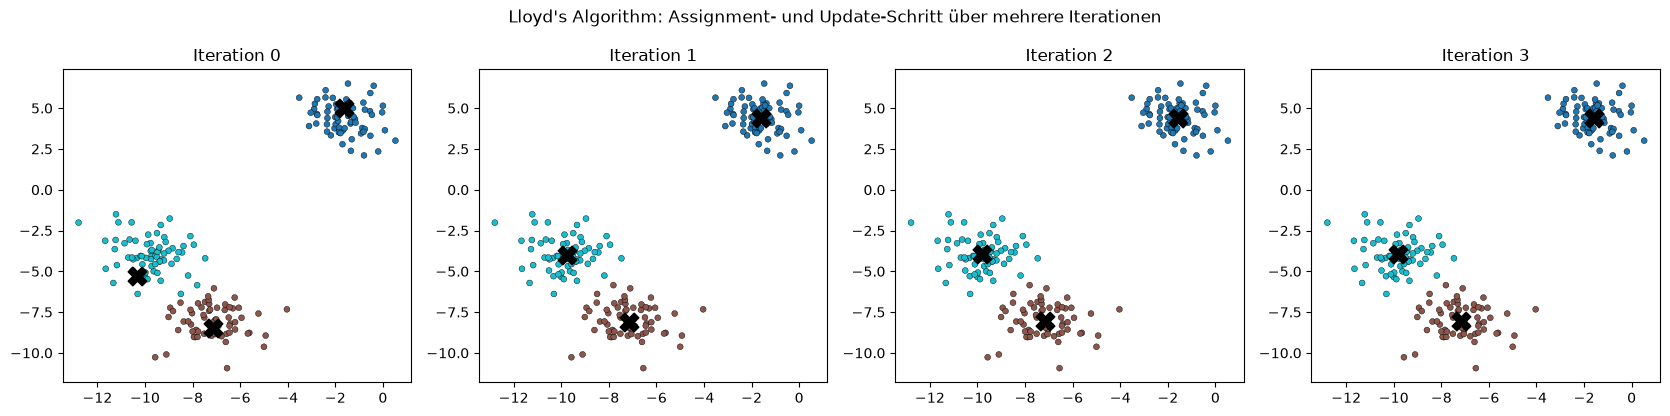

In [4]:
# Lloyd's Algorithm Schritt für Schritt von Hand nachvollzogen
rng = np.random.RandomState(7)
X_lloyd, _ = make_blobs(n_samples=200, centers=3, cluster_std=1.0, random_state=1)

k = 3
init_idx = rng.choice(len(X_lloyd), k, replace=False)
centers = X_lloyd[init_idx].copy()

n_iterations = 4
fig, axes = plt.subplots(1, n_iterations, figsize=(4.2 * n_iterations, 4.2))

for it in range(n_iterations):
    # --- Assignment Step ---
    dists = np.linalg.norm(X_lloyd[:, None, :] - centers[None, :, :], axis=2)
    labels = dists.argmin(axis=1)

    ax = axes[it]
    ax.scatter(X_lloyd[:, 0], X_lloyd[:, 1], c=labels, cmap="tab10", s=18, edgecolor="k", linewidth=0.3)
    ax.scatter(centers[:, 0], centers[:, 1], c="black", marker="X", s=180)
    ax.set_title(f"Iteration {it}")

    # --- Update Step ---
    centers = np.array([
        X_lloyd[labels == j].mean(axis=0) if np.any(labels == j) else centers[j]
        for j in range(k)
    ])

plt.suptitle("Lloyd's Algorithm: Assignment- und Update-Schritt über mehrere Iterationen")
plt.tight_layout()
plt.show()

Man erkennt gut, wie sich die Zentren (schwarze Kreuze) von Iteration zu Iteration in die Mitte ihrer jeweiligen Punktwolke bewegen, bis das Ergebnis stabil ist – bereits nach wenigen Iterationen hat sich der Algorithmus visuell „eingependelt".

### Eigenschaften & Fallstricke

* **Skalierung wichtig:** Features mit großen Werten dominieren die Distanzberechnung → Standardisierung ist fast immer nötig.
* **Nicht robust gegenüber Ausreißern:** Ein Ausreißer zieht den Mittelwert stark mit.
* **Kugelförmige Cluster bevorzugt:** k-Means passt schlecht zu langgezogenen oder nichtlinearen Strukturen.
* **Initialisierung macht großen Unterschied:** k-Means++ ist deutlich stabiler als rein zufällige Startpunkte (in `scikit-learn` bereits der Standard).
* **$k$ muss vorher gewählt werden** – dafür gibt es die Elbow-Methode (siehe unten).


c:\Users\zieher\AppData\Local\miniconda3\envs\mll\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\zieher\AppData\Local\miniconda3\envs\mll\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


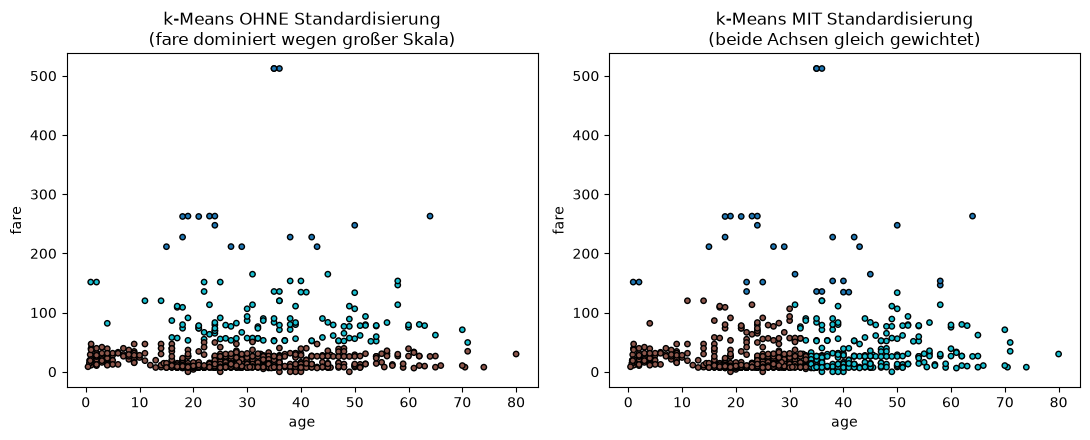

In [5]:
# Warum Skalierung wichtig ist: Demonstration an Titanic-Rohdaten (age vs. fare)
from sklearn.cluster import KMeans as KMeans_scale_demo

raw_features = df[["age", "fare"]].dropna()

km_unscaled = KMeans_scale_demo(n_clusters=3, n_init=10, random_state=42)
labels_unscaled = km_unscaled.fit_predict(raw_features)

scaler_demo = StandardScaler()
raw_scaled = scaler_demo.fit_transform(raw_features)
km_scaled = KMeans_scale_demo(n_clusters=3, n_init=10, random_state=42)
labels_scaled = km_scaled.fit_predict(raw_scaled)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(raw_features["age"], raw_features["fare"], c=labels_unscaled, cmap="tab10", s=15, edgecolor="k")
axes[0].set_title("k-Means OHNE Standardisierung\n(fare dominiert wegen großer Skala)")
axes[0].set_xlabel("age"); axes[0].set_ylabel("fare")

axes[1].scatter(raw_features["age"], raw_features["fare"], c=labels_scaled, cmap="tab10", s=15, edgecolor="k")
axes[1].set_title("k-Means MIT Standardisierung\n(beide Achsen gleich gewichtet)")
axes[1].set_xlabel("age"); axes[1].set_ylabel("fare")

plt.tight_layout()
plt.show()

**Beobachtung:** Ohne Standardisierung dominiert `fare` (Wertebereich bis über 500) die Distanzberechnung fast vollständig gegenüber `age` (Wertebereich bis ca. 80) – die Cluster orientieren sich fast nur an `fare`. Nach der Standardisierung tragen beide Features gleichberechtigt zur Distanz bei, und die Cluster wirken deutlich ausgewogener. Das ist genau der Grund, warum unsere Preprocessing-Pipeline aus Kapitel 2 auch für Clustering unverzichtbar ist.

### Wahl von $k$ – Elbow-Methode

**Idee:** Mehr Cluster $\Rightarrow$ Loss (WCSS) wird kleiner. Aber irgendwann bringt jedes zusätzliche Cluster kaum noch Verbesserung.

**Vorgehen:** WCSS für $k=1,2,\dots,K$ berechnen, gegen $k$ plotten und die Stelle suchen, an der die Kurve „abknickt" (das *Elbow*). Bis zum Knick verbessert sich das Modell stark → sinnvoll. Nach dem Knick: kaum echter Mehrwert.


c:\Users\zieher\AppData\Local\miniconda3\envs\mll\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\zieher\AppData\Local\miniconda3\envs\mll\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\zieher\AppData\Local\miniconda3\envs\mll\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\zieher\AppData\Local\miniconda3\envs\mll\Lib\site-pa

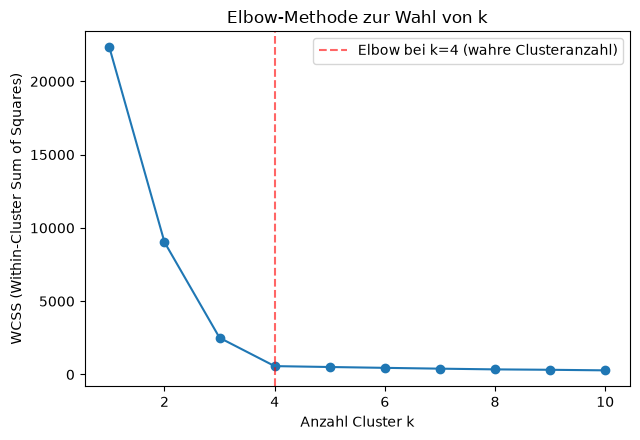

In [6]:
X_elbow, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=7)

wcss = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_elbow)
    wcss.append(km.inertia_)  # inertia_ = WCSS

plt.figure(figsize=(6.5, 4.5))
plt.plot(list(k_range), wcss, "o-")
plt.axvline(4, color="red", linestyle="--", alpha=0.6, label="Elbow bei k=4 (wahre Clusteranzahl)")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.title("Elbow-Methode zur Wahl von k")
plt.legend()
plt.tight_layout()
plt.show()

### Wann ist k-Means geeignet?

**Gut geeignet:**
* Daten liegen in kompakten, annähernd runden Gruppen
* viele Datenpunkte (k-Means skaliert sehr gut)
* eine schnelle, einfache Clusterlösung wird benötigt

**Nicht geeignet:**
* nichtlineare Formen (z. B. Halbmonde)
* Cluster mit sehr unterschiedlicher Dichte
* starker Einfluss von Ausreißern

**Merke:** k-Means ist ein *Linearisierer des Raumes* – gut für „einfache" Cluster, nicht für komplexe Muster. Wir demonstrieren den Grenzfall an unserem Ring-/Halbmond-Beispiel aus dem letzten Notebook.


c:\Users\zieher\AppData\Local\miniconda3\envs\mll\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


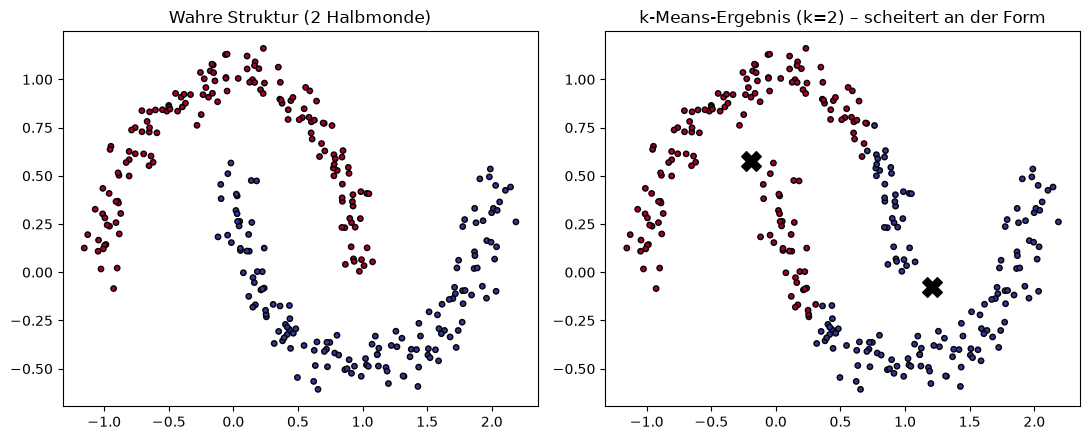

In [7]:
from sklearn.datasets import make_moons

X_moons, y_moons_true = make_moons(n_samples=300, noise=0.07, random_state=42)

km_moons = KMeans(n_clusters=2, n_init=10, random_state=42)
labels_moons = km_moons.fit_predict(X_moons)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons_true, cmap="RdYlBu", s=15, edgecolor="k")
axes[0].set_title("Wahre Struktur (2 Halbmonde)")

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_moons, cmap="RdYlBu", s=15, edgecolor="k")
axes[1].scatter(km_moons.cluster_centers_[:, 0], km_moons.cluster_centers_[:, 1],
                marker="X", c="black", s=200)
axes[1].set_title("k-Means-Ergebnis (k=2) – scheitert an der Form")

plt.tight_layout()
plt.show()

**Beobachtung:** k-Means teilt die Halbmonde einfach entlang einer geraden Linie in zwei Hälften – die eigentliche, nichtlineare Struktur wird komplett verfehlt. Das illustriert exakt die Grenze von k-Means: Es kann nur **konvexe, kompakte** Cluster finden, keine beliebig geformten.

### k-Means auf dem Titanic-Datensatz

Wenden wir k-Means nun auf unsere vorbereiteten Titanic-Daten an – ganz im Sinne des „Kundensegmente"-Beispiels aus Kapitel 1, nur eben mit Passagieren statt Kunden. Wir clustern **ohne** die Zielvariable `survived` und schauen sie uns erst danach an, um die gefundenen Gruppen zu interpretieren.


In [8]:
kmeans_titanic = KMeans(n_clusters=3, n_init=10, random_state=42)
titanic_clusters = kmeans_titanic.fit_predict(X_trans)

titanic_summary = df.assign(cluster=titanic_clusters).groupby("cluster").agg(
    n_passagiere=("survived", "size"),
    ueberlebensrate=("survived", "mean"),
    durchschnittsalter=("age", "mean"),
    durchschnittspreis=("fare", "mean"),
    haeufigste_klasse=("pclass", lambda s: s.mode().iloc[0]),
    anteil_weiblich=("sex", lambda s: (s == "female").mean()),
).round(2)

titanic_summary

c:\Users\zieher\AppData\Local\miniconda3\envs\mll\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


,n_passagiere,ueberlebensrate,durchschnittsalter,durchschnittspreis,haeufigste_klasse,anteil_weiblich
cluster,,,,,,
0,185,0.52,17.55,28.74,3,0.68
1,501,0.23,29.96,11.80,3,0.18
2,205,0.63,39.68,85.19,1,0.48


### Interpretation

Auch ohne dass das Modell die Zielvariable `survived` je gesehen hat, entstehen Cluster, die sich deutlich in **Überlebensrate, Ticketpreis, Klasse und Geschlechterverteilung** unterscheiden – ganz ähnlich wie die „Kundensegmente" aus der Vorlesung. Das ist ein schönes Beispiel für **Was lernt das Modell?**: k-Means erkennt Gruppen rein aus der Ähnlichkeit der Passagiere in den Eingabedaten – die Tatsache, dass diese Gruppen sich zufällig auch in der Überlebensrate unterscheiden, zeigt, dass Klasse, Ticketpreis und Geschlecht (die ja auch in den Baseline-Modellen wichtige Features waren) eng mit der Überlebenswahrscheinlichkeit zusammenhängen.

### Fazit Kapitel 3

* k-Means gruppiert Daten, indem es Punkte iterativ dem nächstgelegenen von $k$ Zentren zuordnet und die Zentren als Mittelwerte neu berechnet (Lloyd's Algorithm).
* Standardisierung der Features ist praktisch **Pflicht**.
* Die Elbow-Methode hilft bei der Wahl von $k$.
* k-Means funktioniert gut für kompakte, kugelförmige Cluster, scheitert aber an nichtlinearen Formen.
* Angewendet auf Titanic entdeckt k-Means sinnvolle, interpretierbare Passagiergruppen – völlig ohne die Zielvariable zu nutzen.


## Kapitel 4: Principal Component Analysis (PCA)

### Intuition

**Ziel:** Hohe Dimensionen auf wenige Dimensionen reduzieren, ohne die wesentliche Struktur zu verlieren.

**Kernidee:** Daten variieren nicht in allen Richtungen gleich stark. PCA findet die Richtung, in der die Daten am stärksten streuen – diese Richtung ist die **1. Hauptkomponente**. Große Varianz bedeutet viel Information, kleine Varianz eher Rauschen.

PCA ist im Kern eine **Rotation**: Wir drehen das Koordinatensystem so, dass die erste Achse die meiste Varianz erklärt.


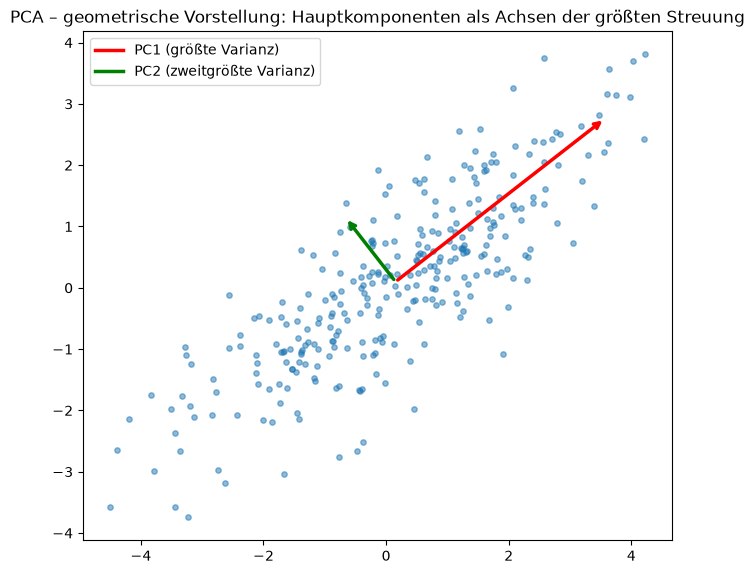

In [9]:
from sklearn.decomposition import PCA

# Künstliche, korrelierte 2D-Daten (Punktewolke, länglich/ellipsenartig)
rng = np.random.RandomState(0)
mean_2d = [0, 0]
cov_2d = [[3, 2], [2, 2]]  # positiv semidefinite Kovarianzmatrix -> korrelierte Daten
X_2d = rng.multivariate_normal(mean_2d, cov_2d, size=300)

pca_2d = PCA(n_components=2)
pca_2d.fit(X_2d)
mean_point = X_2d.mean(axis=0)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(X_2d[:, 0], X_2d[:, 1], s=15, alpha=0.5)

colors = ["red", "green"]
labels_pc = ["PC1 (größte Varianz)", "PC2 (zweitgrößte Varianz)"]
for i in range(2):
    vec = pca_2d.components_[i] * np.sqrt(pca_2d.explained_variance_[i]) * 2
    ax.annotate("", xy=mean_point + vec, xytext=mean_point,
                arrowprops=dict(arrowstyle="->", linewidth=2.5, color=colors[i]))
    ax.plot([], [], color=colors[i], label=labels_pc[i], linewidth=2.5)

ax.set_aspect("equal")
ax.set_title("PCA – geometrische Vorstellung: Hauptkomponenten als Achsen der größten Streuung")
ax.legend()
plt.tight_layout()
plt.show()

**Beobachtung:** PC1 zeigt entlang der langen Achse der Punktewolke (Richtung der größten Streuung), PC2 steht senkrecht darauf und zeigt entlang der zweitgrößten Streuung. Die Projektion der Daten auf diese Achsen entspricht dem „Schatten" der Punktewolke auf die jeweilige Richtung.

### Mathematische Formulierung

Gegeben: eine zentrierte Datenmatrix $X \in \mathbb{R}^{n\times d}$. Gesucht ist die Richtung $w$ (mit $\lVert w \rVert = 1$), die die maximale Varianz erzeugt:

$$
\max_{\lVert w \rVert = 1} \text{Var}(Xw) = \max_{\lVert w \rVert = 1} w^\top S w, \qquad S = \frac{1}{n} X^\top X \ \text{(Kovarianzmatrix)}
$$

**Lösung:** $w$ ist der Eigenvektor von $S$ mit dem größten Eigenwert; der Eigenwert entspricht der erklärten Varianz dieser Komponente.

**Warum Eigenvektoren?** Ein Eigenvektor ist eine Richtung, die sich unter der Transformation durch $S$ nicht verdreht – nur skaliert. Die Kovarianzmatrix $S$ beschreibt die Streuung der Daten; ein Eigenvektor von $S$ zeigt daher in eine Richtung, in der die Daten „konsistent" (gleichmäßig, ohne Verdrehung) variieren. Der zugehörige Eigenwert misst, wie stark die Streuung in dieser Richtung ist. PCA sortiert also die Richtungen einfach nach ihrer erklärten Varianz.

Wir prüfen das direkt nach: Eine manuell in NumPy berechnete Eigenzerlegung der Kovarianzmatrix sollte exakt dieselben Hauptkomponenten liefern wie `sklearn.decomposition.PCA`.


In [10]:
X_centered = X_2d - X_2d.mean(axis=0)
n_samples = X_centered.shape[0]

# Kovarianzmatrix S = (1/n) X^T X
S = (X_centered.T @ X_centered) / n_samples

# Eigenzerlegung (np.linalg.eigh, da S symmetrisch ist)
eigvals, eigvecs = np.linalg.eigh(S)
order = np.argsort(eigvals)[::-1]     # absteigend sortieren
eigvals_sorted = eigvals[order]
eigvecs_sorted = eigvecs[:, order]

print("Manuell berechnete Eigenwerte (erklärte Varianz):", eigvals_sorted)
print("Manuell berechneter Eigenvektor zu PC1:          ", eigvecs_sorted[:, 0])
print()
print("sklearn PCA explained_variance_:                 ", pca_2d.explained_variance_)
print("sklearn PCA components_ (PC1):                    ", pca_2d.components_[0])

Manuell berechnete Eigenwerte (erklärte Varianz): [4.66099358 0.43422169]
Manuell berechneter Eigenvektor zu PC1:           [-0.78888067 -0.61454641]

sklearn PCA explained_variance_:                  [4.67658219 0.43567394]
sklearn PCA components_ (PC1):                     [0.78888067 0.61454641]


Die Werte stimmen (bis auf das Vorzeichen des Eigenvektors, das mathematisch beliebig ist) exakt überein – `PCA` in `scikit-learn` tut also nichts anderes, als die Eigenzerlegung der Kovarianzmatrix zu berechnen (intern über eine numerisch stabilere Singulärwertzerlegung, SVD).

### Konkretes Beispiel: PCA auf Bildern (Digits)

Analog zum MNIST-Beispiel aus der Vorlesung (784 Dimensionen) wenden wir PCA auf unseren Digits-Datensatz an (64 Dimensionen) und reduzieren auf 2 Dimensionen zur Visualisierung.


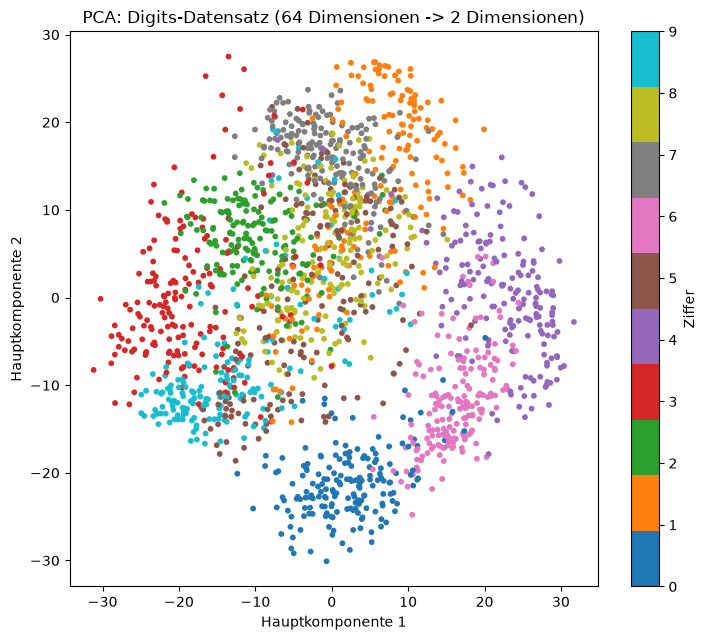

Erklärte Varianz PC1 + PC2: 28.5%


In [11]:
pca_digits_2d = PCA(n_components=2)
X_digits_2d = pca_digits_2d.fit_transform(digits.data)

plt.figure(figsize=(7.5, 6.5))
scatter = plt.scatter(X_digits_2d[:, 0], X_digits_2d[:, 1], c=digits.target, cmap="tab10", s=10)
plt.colorbar(scatter, label="Ziffer")
plt.xlabel("Hauptkomponente 1")
plt.ylabel("Hauptkomponente 2")
plt.title("PCA: Digits-Datensatz (64 Dimensionen -> 2 Dimensionen)")
plt.tight_layout()
plt.show()

print(f"Erklärte Varianz PC1 + PC2: {pca_digits_2d.explained_variance_ratio_.sum():.1%}")

**Beobachtung:** Obwohl PCA rein linear ist und komplett ohne Kenntnis der Ziffern-Labels arbeitet, bilden sich bereits in 2 Dimensionen erkennbare Gruppen – ähnliche Ziffern (z. B. runde Formen wie "0" und "6") liegen tendenziell näher beieinander als sehr unterschiedliche Ziffern. Mit nur 2 von 64 Dimensionen erklären wir allerdings nur einen Bruchteil der Gesamtvarianz – für eine gute Klassifikation bräuchte man deutlich mehr Komponenten.

**Wie viele Komponenten braucht man?** Analog zur Elbow-Methode bei k-Means schauen wir uns die kumulierte erklärte Varianz an – hier für die Digits-Daten.


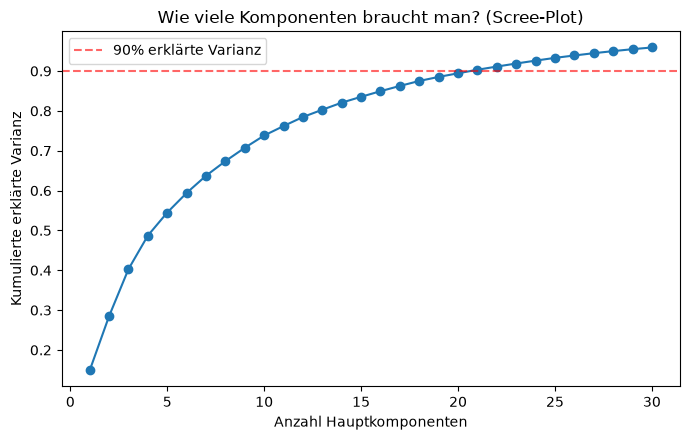

Anzahl Komponenten für ≥90% erklärte Varianz: 21


In [12]:
pca_digits_full = PCA(n_components=30).fit(digits.data)
cum_var = np.cumsum(pca_digits_full.explained_variance_ratio_)

plt.figure(figsize=(7, 4.5))
plt.plot(range(1, 31), cum_var, "o-")
plt.axhline(0.90, color="red", linestyle="--", alpha=0.6, label="90% erklärte Varianz")
plt.xlabel("Anzahl Hauptkomponenten")
plt.ylabel("Kumulierte erklärte Varianz")
plt.title("Wie viele Komponenten braucht man? (Scree-Plot)")
plt.legend()
plt.tight_layout()
plt.show()

n_for_90 = np.argmax(cum_var >= 0.90) + 1
print(f"Anzahl Komponenten für ≥90% erklärte Varianz: {n_for_90}")

Mit rund 20 statt 64 Dimensionen lassen sich bereits über 90 % der Varianz erklären – eine deutliche Kompression bei geringem Informationsverlust. Wie stark sich die Bilder bei einer solchen Kompression optisch verändern, zeigen wir anhand einer Rekonstruktion mit nur 10 Hauptkomponenten.


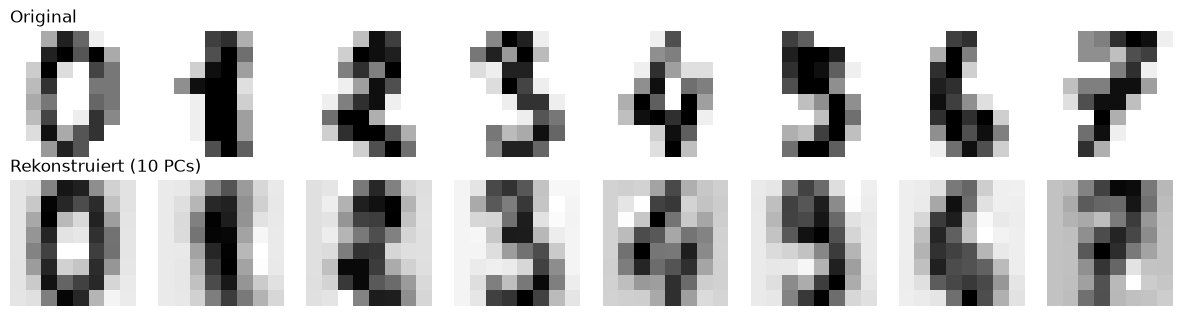

Erklärte Varianz mit 10 Komponenten: 73.8%


In [13]:
pca_reconstruct = PCA(n_components=10).fit(digits.data)
X_projected = pca_reconstruct.transform(digits.data)
X_reconstructed = pca_reconstruct.inverse_transform(X_projected)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i in range(8):
    axes[0, i].imshow(digits.images[i], cmap="gray_r")
    axes[0, i].axis("off")
    axes[1, i].imshow(X_reconstructed[i].reshape(8, 8), cmap="gray_r")
    axes[1, i].axis("off")

axes[0, 0].set_title("Original", loc="left")
axes[1, 0].set_title("Rekonstruiert (10 PCs)", loc="left")
plt.tight_layout()
plt.show()

print(f"Erklärte Varianz mit 10 Komponenten: {pca_reconstruct.explained_variance_ratio_.sum():.1%}")

Genau wie in der Vorlesung beschrieben: Die rekonstruierten Bilder sind sichtbar unschärfer, aber die grundlegende Struktur (welche Ziffer es ist) bleibt klar erkennbar – bei einer Kompression von 64 auf nur 10 Dimensionen.

### PCA zur Visualisierung des Titanic-Datensatzes

Genau wie Digits lässt sich auch unser (bereits standardisierter und one-hot-kodierter) Titanic-Datensatz per PCA auf 2 Dimensionen reduzieren und visualisieren.


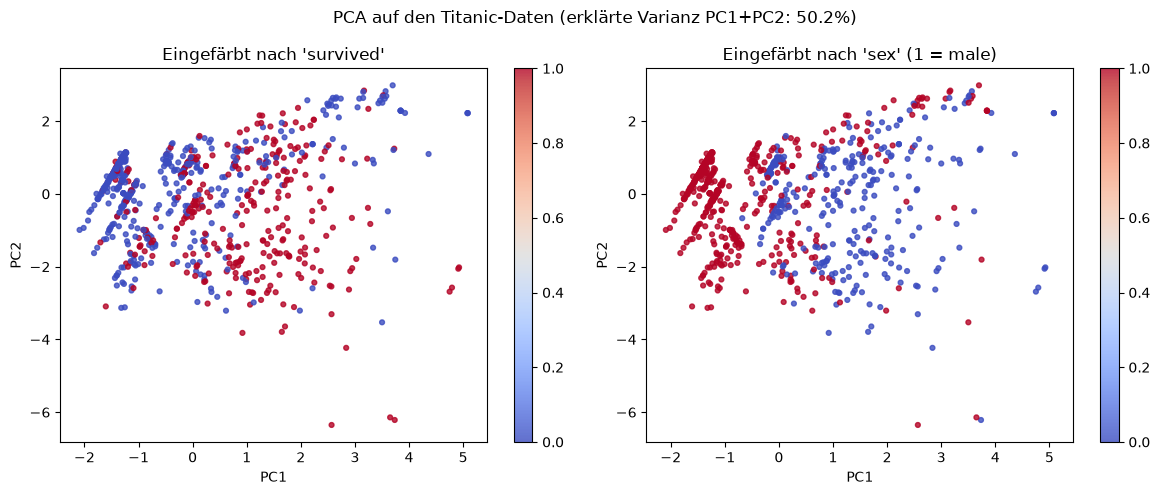

In [14]:
pca_titanic = PCA(n_components=2)
X_titanic_2d = pca_titanic.fit_transform(X_trans)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc0 = axes[0].scatter(X_titanic_2d[:, 0], X_titanic_2d[:, 1], c=y, cmap="coolwarm", s=12, alpha=0.8)
axes[0].set_title("Eingefärbt nach 'survived'")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
plt.colorbar(sc0, ax=axes[0])

sex_numeric = (df["sex"] == "male").astype(int)
sc1 = axes[1].scatter(X_titanic_2d[:, 0], X_titanic_2d[:, 1], c=sex_numeric, cmap="coolwarm", s=12, alpha=0.8)
axes[1].set_title("Eingefärbt nach 'sex' (1 = male)")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[1])

plt.suptitle(f"PCA auf den Titanic-Daten (erklärte Varianz PC1+PC2: {pca_titanic.explained_variance_ratio_.sum():.1%})")
plt.tight_layout()
plt.show()

**Beobachtung:** Auch ohne dass PCA jemals die Zielvariable gesehen hat, zeichnen sich in der 2D-Projektion sichtbare Strukturen ab, die mit `sex` und – etwas schwächer – mit `survived` zusammenhängen. Das bestätigt, was wir bereits aus den Baseline-Modellen und der SHAP-Analyse wissen: Geschlecht ist eines der stärksten Signale im Titanic-Datensatz. PCA macht diese Struktur rein aus der Varianz der Eingabedaten heraus sichtbar – genau wie in der Vorlesung am Beispiel von Iris- und Titanic-Daten beschrieben.

### PCA – Eigenschaften & Fallstricke

**Vorteile:**
* sehr schnell (SVD-basiert)
* starkes Werkzeug zur Visualisierung
* reduziert Rauschen
* oft gutes Preprocessing für nachgelagerte ML-Modelle

**Nachteile:**
* PCA ist **linear** – erkennt keine nichtlinearen Muster
* sensibel gegenüber der Skalierung der Features
* Hauptkomponenten sind oft schwer interpretierbar (sie sind Linearkombinationen aller Ursprungsfeatures)
* erklärt Varianz, **nicht** Klassen – zwei Klassen können sich in einer Richtung mit wenig Varianz unterscheiden und von PCA daher "übersehen" werden

**Merke:** PCA findet Struktur – keine Zielvariablen.

### Wann ist PCA geeignet?

**Gut geeignet:**
* Daten mit Korrelationen zwischen Features
* explorative Analyse / Visualisierung
* Rauschreduktion
* Preprocessing vor Clustering (z. B. vor k-Means)

**Nicht geeignet:**
* stark nichtlineare Strukturen (z. B. "Swiss Roll")
* Kategorien, die nicht durch Varianz getrennt sind
* Daten mit unterschiedlicher Skalierung ohne vorherige Standardisierung

**Merke:** PCA zeigt, wie die Daten variieren – nicht, wie sie klassifiziert werden.


### Fazit Kapitel 4

* PCA findet die Richtungen größter Varianz in den Daten (Hauptkomponenten) durch Eigenzerlegung der Kovarianzmatrix.
* Geometrisch ist PCA eine Rotation des Koordinatensystems.
* Bereits wenige Hauptkomponenten können einen Großteil der Varianz hochdimensionaler Daten (Bilder, Titanic-Features) erklären.
* PCA ist ein rein exploratives, lineares Werkzeug – es ersetzt kein Klassifikationsmodell, kann aber Struktur sichtbar machen und als Preprocessing dienen.


## Kapitel 5: Ausblick – weitere Methoden

k-Means und PCA sind die am häufigsten eingesetzten, "klassischen" Vertreter von Clustering und Dimensionsreduktion – aber bei Weitem nicht die einzigen. Ein kurzer Überblick über verwandte Methoden, die den Rahmen dieses Labs sprengen würden, aber gutes Anschlusswissen darstellen:

**Weitere Clustering-Verfahren:**
* **Hierarchical Clustering** – baut eine Baumstruktur (Dendrogramm) von Clustern auf, ohne $k$ vorher festzulegen.
* **DBSCAN** – dichtebasiertes Clustering, findet auch nichtlineare Cluster-Formen und erkennt Ausreißer automatisch als "Rauschen".

**Weitere Dimensionsreduktionsverfahren:**
* **t-SNE / UMAP** – nichtlineare Verfahren, die besonders gut für die *Visualisierung* hochdimensionaler Daten (z. B. Bild- oder Text-Embeddings) geeignet sind, aber nicht wie PCA linear invertierbar sind.

**Dichteschätzung:**
* **Kernel Density Estimation (KDE)** und **Gaussian Mixture Models (GMM)** modellieren die Wahrscheinlichkeitsdichte $p(x)$ direkt und eignen sich z. B. gut für Anomalieerkennung (siehe Fraud-Beispiel aus Kapitel 1).

**Representation Learning:**
* **Autoencoder** – neuronale Netze, die lernen, Daten komprimiert zu kodieren und wieder zu rekonstruieren (eine nichtlineare Verallgemeinerung von PCA – siehe letztes Notebook zu neuronalen Netzen).
* **Embedding-Modelle** (Word2Vec, moderne Sprachmodelle) – lernen bedeutungsvolle Vektorrepräsentationen für Wörter, Sätze oder andere Objekte.

Diese Methoden sind fester Bestandteil weiterführender Veranstaltungen zu Data Mining, Deep Learning und Natural Language Processing.


## Kapitel 6: Fazit

In diesem Notebook haben wir einen kompakten Überblick über **Unsupervised Learning** erarbeitet:

* **Grundidee:** Muster in Daten $X$ ohne Labels $y$ finden – es gibt kein "richtig/falsch", nur "nützlich oder nicht".
* **Vier Hauptfamilien:** Clustering, Dimensionsreduktion, Dichteschätzung, Representation Learning.
* **k-Means:** iterativer Algorithmus (Assignment + Update), der Daten in $k$ kompakte, kugelförmige Cluster einteilt; Standardisierung und die Wahl von $k$ (Elbow-Methode) sind entscheidend; scheitert an nichtlinearen Strukturen.
* **PCA:** findet die Richtungen größter Varianz mittels Eigenzerlegung der Kovarianzmatrix; ideal zur Visualisierung, Rauschreduktion und als Preprocessing – aber rein linear und ohne Bezug zu Zielvariablen.
* Angewendet auf unseren bekannten Titanic-Datensatz zeigen beide Methoden, wie viel Struktur bereits **ohne** die Zielvariable `survived` sichtbar wird – ein schönes Schlussbild für das gesamte Semester: Von der einfachen logistischen Regression über Bäume, Ensembles und neuronale Netze bis hin zu Methoden, die ganz ohne Labels auskommen.

Damit ist das Machine Learning Lab inhaltlich abgeschlossen. Wir hoffen, der Überblick über den gesamten "Werkzeugkasten" des Machine Learning – von linearen Modellen über Bäume und Ensembles bis zu neuronalen Netzen und Unsupervised Learning – gibt Ihnen ein solides Fundament für eigene Projekte in Ihrem weiteren Studium und Berufsleben!
